<a href="https://colab.research.google.com/github/Dima-BR/machine-learning-projects/blob/main/Predict_Course_Popularity_on_Udemy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

1. Understand Dataset

2. Data Cleaning
   - duplicates
   - datatype fixing
   - formatting

3. EDA
   - Univariate Analysis
   - Bivariate Analysis
   - Correlation Analysis

4. Feature Engineering
    - create new features

5. Data Preprocessing
   - missing values
   - categorical encoding
   - outliers
   - feature selection

6. Split Dataset

7. Feature Scaling
   - StandardScaler / MinMaxScaler

8. ML Modeling

9. Model Evaluation

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Model Selection
from sklearn.model_selection import train_test_split

## Metrics
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score

## Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder , MinMaxScaler
# from sklearn_features.transformers import DataFrameSelector

## Models
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
import xgboost

## other
import missingno as msno

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

# pd.set_option('display.max_colwidth', 9990)

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
## pd.set_option('display.max_colwidth', None)
# pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# udemyDf = pd.read_csv("/content/UdemyCoursesDataset.csv")
# udemyDf = pd.read_csv(r'/kaggle/input/udemy-courses-dataset/UdemyCoursesDataset.csv')
udemyDf = pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/datasets/UdemyCoursesDataset.csv')


# Exploring Data:

In [ ]:
udemyDf.head(20)

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,288942,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,1.5 hours,2014-09-18T05:07:05Z,Musical Instruments
1,1170074,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593,1,41,Intermediate Level,1 hour,2017-04-12T19:06:34Z,Musical Instruments
2,1193886,#12 Hand Coordination: Let your Hands dance wi...,True,75,482,1,47,Intermediate Level,1.5 hours,2017-04-26T18:34:57Z,Musical Instruments
3,1116700,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850,3,43,Intermediate Level,1 hour,2017-02-21T23:48:18Z,Musical Instruments
4,1120410,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940,3,32,Intermediate Level,37 mins,2017-02-21T23:44:49Z,Musical Instruments
5,1122832,#6 Piano Hand Coordination: Play Open 10 Balla...,True,65,2015,3,21,Intermediate Level,44 mins,2017-03-08T17:53:36Z,Musical Instruments
6,1123184,#7 Piano Hand Coordination: Play Piano Runs in...,True,65,2015,2,25,Intermediate Level,1 hour,2017-03-08T18:09:32Z,Musical Instruments
7,768028,* An Integrated Approach to the Fundamentals o...,True,200,134,14,123,All Levels,5.5 hours,2016-03-15T17:23:07Z,Business Finance
8,206592,:::Beginners Guide To Creating Amazing Images ...,True,25,72,5,17,Beginner Level,1 hour,2014-04-29T19:50:31Z,Graphic Design
9,738910,[Value Investing] Where White People Keep Thei...,True,200,2715,70,20,Expert Level,4 hours,2016-05-25T21:04:41Z,Business Finance


In [ ]:
udemyDf.shape

(3682, 11)

In [ ]:
udemyDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3682 entries, 0 to 3681
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   course_id            3682 non-null   int64 
 1   course_title         3682 non-null   object
 2   is_paid              3682 non-null   bool  
 3   price                3682 non-null   object
 4   num_subscribers      3682 non-null   int64 
 5   num_reviews          3682 non-null   int64 
 6   num_lectures         3682 non-null   int64 
 7   level                3682 non-null   object
 8   content_duration     3682 non-null   object
 9   published_timestamp  3682 non-null   object
 10  subject              3682 non-null   object
dtypes: bool(1), int64(4), object(6)
memory usage: 291.4+ KB


In [ ]:
udemyDf.describe()

,course_id,num_subscribers,num_reviews,num_lectures
count,3.682000e+03,3682.000000,3682.000000,3682.000000
mean,6.766121e+05,3194.230310,156.093156,40.065182
std,3.436355e+05,9499.378361,934.957204,50.373299
min,8.324000e+03,0.000000,0.000000,0.000000
25%,4.078430e+05,110.250000,4.000000,15.000000
50%,6.885580e+05,911.500000,18.000000,25.000000
75%,9.617515e+05,2540.250000,67.000000,45.000000
max,1.282064e+06,268923.000000,27445.000000,779.000000


In [ ]:
udemyDf.head(10).style.background_gradient(cmap='Purples')

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,288942,#1 Piano Hand Coordination: Play 10th Ballad in Eb Key songs,True,35,3137,18,68,All Levels,1.5 hours,2014-09-18T05:07:05Z,Musical Instruments
1,1170074,#10 Hand Coordination - Transfer Chord Ballad 9 - C & Bb Key,True,75,1593,1,41,Intermediate Level,1 hour,2017-04-12T19:06:34Z,Musical Instruments
2,1193886,#12 Hand Coordination: Let your Hands dance with Ballad 9,True,75,482,1,47,Intermediate Level,1.5 hours,2017-04-26T18:34:57Z,Musical Instruments
3,1116700,#4 Piano Hand Coordination: Fun Piano Runs in 2 Beats C Key,True,75,850,3,43,Intermediate Level,1 hour,2017-02-21T23:48:18Z,Musical Instruments
4,1120410,#5 Piano Hand Coordination: Piano Runs in 2 Beats Eb Key,True,75,940,3,32,Intermediate Level,37 mins,2017-02-21T23:44:49Z,Musical Instruments
5,1122832,#6 Piano Hand Coordination: Play Open 10 Ballad to 9/4 Song,True,65,2015,3,21,Intermediate Level,44 mins,2017-03-08T17:53:36Z,Musical Instruments
6,1123184,#7 Piano Hand Coordination: Play Piano Runs in 3 Beats 9/4,True,65,2015,2,25,Intermediate Level,1 hour,2017-03-08T18:09:32Z,Musical Instruments
7,768028,* An Integrated Approach to the Fundamentals of Accounting,True,200,134,14,123,All Levels,5.5 hours,2016-03-15T17:23:07Z,Business Finance
8,206592,:::Beginners Guide To Creating Amazing Images with Canva:::,True,25,72,5,17,Beginner Level,1 hour,2014-04-29T19:50:31Z,Graphic Design
9,738910,[Value Investing] Where White People Keep Their Money,True,200,2715,70,20,Expert Level,4 hours,2016-05-25T21:04:41Z,Business Finance


In [ ]:
udemyDf.duplicated().sum()

np.int64(6)

In [ ]:
udemyDf.isnull().sum()

,0
course_id,0
course_title,0
is_paid,0
price,0
num_subscribers,0
num_reviews,0
num_lectures,0
level,0
content_duration,0
published_timestamp,0


In [ ]:
udemyDf.isna().sum()

,0
course_id,0
course_title,0
is_paid,0
price,0
num_subscribers,0
num_reviews,0
num_lectures,0
level,0
content_duration,0
published_timestamp,0


In [ ]:
categorical_cols = udemyDf.select_dtypes(include=['object', 'category']).columns
categorical_cols

Index(['course_title', 'price', 'level', 'content_duration',
       'published_timestamp', 'subject'],
      dtype='object')

In [ ]:
unique_values = udemyDf['content_duration'].unique()
print("Unique values before conversion:")
print(unique_values)

import re
pattern = r'(hour|min)'
unusual = [x for x in unique_values if not re.search(pattern, str(x).lower())]
print(f"\nUnusual values (no hour/min): {unusual}")

Unique values before conversion:
['1.5 hours' '1 hour' '37 mins' '44 mins' '5.5 hours' '4 hours' '31 mins'
 '2.5 hours' '6.5 hours' '3 hours' '8.5 hours' '4.5 hours' '9.5 hours'
 '2 hours' '3.5 hours' '9 hours' '5 hours' '36 mins' '16 hours' '32 mins'
 '14 hours' '35 mins' '6 hours' '41 mins' '7.5 hours' '14.5 hours'
 '24.5 hours' '33 mins' '29 hours' '13.5 hours' '42 mins' '33 hours'
 '12.5 hours' '8 hours' '7 hours' '34 mins' '11.5 hours' '62 hours'
 '12 hours' '39 mins' '19 mins' '15.5 hours' '10.5 hours' '21 hours'
 '68.5 hours' '19.5 hours' '20.5 hours' '22 hours' '10 hours' '38 mins'
 '43 mins' '40 mins' '24 hours' '13 hours' '31.5 hours' '44.5 hours'
 '17.5 hours' '48.5 hours' '60 hours' '11 hours' '27.5 hours' '18.5 hours'
 '25.5 hours' '22.5 hours' '16.5 hours' '30 mins' '57 hours' '45 hours'
 '20 hours' '39 hours' '34 hours' '25 hours' '26 hours' '29.5 hours'
 '15 hours' '37.5 hours' '71.5 hours' '47 hours' '18 hours' '38 hours'
 '28.5 hours' '8 mins' '32.5 hours' '31 hours' 

## 1. Data Quality Questions and Answers

* **Are there missing values in critical columns?** No

* **Are there duplicate courses?** Yes, there are 6 duplicate rows.
    * *I will drop them when cleaning the dataset.*

* **Are data types correct?** No. `content_duration`, `published_timestamp`, and `price` have the wrong data types. They are currently **objects** and should be converted to **numeric/datetime**.

* **Are there outliers in price or number of subscribers?** Yes

****

# Clean Dataset

In [ ]:
# Check and remove duplicates
duplicates = udemyDf.duplicated().sum()
if duplicates > 0:
  udemyDf.drop_duplicates(inplace=True)

In [ ]:
# Convert price columns to numeric
udemyDf['price'] = udemyDf['price'].astype(str).str.replace('$', '').str.replace(',', '').str.replace('Free', '0')
udemyDf['price'] = pd.to_numeric(udemyDf['price'], errors='coerce')

udemyDf['price'].dtype
udemyDf['price'].tail(10)

,price
3672,20
3673,25
3674,0
3675,70
3676,200
3677,120
3678,70
3679,40
3680,0
3681,50


In [ ]:
# published_timestamp
udemyDf['published_timestamp'] = pd.to_datetime(udemyDf['published_timestamp'], errors='coerce')

In [ ]:
unique_values = udemyDf['content_duration'].unique()
print("Unique values before conversion:")
print(unique_values)

Unique values before conversion:
['1.5 hours' '1 hour' '37 mins' '44 mins' '5.5 hours' '4 hours' '31 mins'
 '2.5 hours' '6.5 hours' '3 hours' '8.5 hours' '4.5 hours' '9.5 hours'
 '2 hours' '3.5 hours' '9 hours' '5 hours' '36 mins' '16 hours' '32 mins'
 '14 hours' '35 mins' '6 hours' '41 mins' '7.5 hours' '14.5 hours'
 '24.5 hours' '33 mins' '29 hours' '13.5 hours' '42 mins' '33 hours'
 '12.5 hours' '8 hours' '7 hours' '34 mins' '11.5 hours' '62 hours'
 '12 hours' '39 mins' '19 mins' '15.5 hours' '10.5 hours' '21 hours'
 '68.5 hours' '19.5 hours' '20.5 hours' '22 hours' '10 hours' '38 mins'
 '43 mins' '40 mins' '24 hours' '13 hours' '31.5 hours' '44.5 hours'
 '17.5 hours' '48.5 hours' '60 hours' '11 hours' '27.5 hours' '18.5 hours'
 '25.5 hours' '22.5 hours' '16.5 hours' '30 mins' '57 hours' '45 hours'
 '20 hours' '39 hours' '34 hours' '25 hours' '26 hours' '29.5 hours'
 '15 hours' '37.5 hours' '71.5 hours' '47 hours' '18 hours' '38 hours'
 '28.5 hours' '8 mins' '32.5 hours' '31 hours' 

In [ ]:
# def convert_duration(duration):
#     duration = str(duration).lower().strip()

#     if 'hour' in duration:
#         number = float(duration.replace('hours', '')
#                                .replace('hour', '')
#                                .strip())
#         return number * 60

#     elif 'min' in duration:
#         number = float(duration.replace('mins', '')
#                                .replace('min', '')
#                                .strip())
#         return number

#     else:
#         return None

# udemyDf['content_duration'] = udemyDf['content_duration'].apply(convert_duration)

In [ ]:
def convert_duration(duration):
    duration = str(duration).lower().strip()

    # Mark invalid rows
    if 'question' in duration or duration == '0':
        return None

    # Convert hours to minutes
    elif 'hour' in duration:
        number = float(duration.replace('hours', '')
                               .replace('hour', '')
                               .strip())
        return number * 60

    # Keep minutes as they are
    elif 'min' in duration:
        number = float(duration.replace('mins', '')
                               .replace('min', '')
                               .strip())
        return number


# Apply conversion
udemyDf['content_duration'] = udemyDf['content_duration'].apply(convert_duration)

# Remove invalid rows automatically
udemyDf = udemyDf.dropna(subset=['content_duration'])

# Ensure numeric datatype
udemyDf['content_duration'] = pd.to_numeric(
    udemyDf['content_duration']
)

# Check datatype
print(udemyDf['content_duration'].dtype)

float64


In [ ]:
udemyDf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3671 entries, 0 to 3681
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   course_id            3671 non-null   int64              
 1   course_title         3671 non-null   object             
 2   is_paid              3671 non-null   bool               
 3   price                3671 non-null   int64              
 4   num_subscribers      3671 non-null   int64              
 5   num_reviews          3671 non-null   int64              
 6   num_lectures         3671 non-null   int64              
 7   level                3671 non-null   object             
 8   content_duration     3671 non-null   float64            
 9   published_timestamp  3671 non-null   datetime64[ns, UTC]
 10  subject              3671 non-null   object             
dtypes: bool(1), datetime64[ns, UTC](1), float64(1), int64(5), object(3)
memory usage: 319.1

In [ ]:
udemyDf['content_duration']

,content_duration
0,90.0
1,60.0
2,90.0
3,60.0
4,37.0
...,...
3677,240.0
3678,300.0
3679,390.0
3680,120.0


In [ ]:
udemyDf['content_duration'].describe()

,content_duration
count,3671.000000
mean,245.923182
std,363.496644
min,8.000000
25%,60.000000
50%,120.000000
75%,270.000000
max,4710.000000


In [ ]:
udemyDf['num_subscribers'].describe()

,num_subscribers
count,3671.000000
mean,3191.456007
std,9489.251824
min,0.000000
25%,112.000000
50%,912.000000
75%,2550.500000
max,268923.000000


In [ ]:
udemyDf.dtypes

,0
course_id,int64
course_title,object
is_paid,bool
price,int64
num_subscribers,int64
num_reviews,int64
num_lectures,int64
level,object
content_duration,float64
published_timestamp,"datetime64[ns, UTC]"


In [ ]:
udemyDf.head(20)

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,288942,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,90.0,2014-09-18 05:07:05+00:00,Musical Instruments
1,1170074,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593,1,41,Intermediate Level,60.0,2017-04-12 19:06:34+00:00,Musical Instruments
2,1193886,#12 Hand Coordination: Let your Hands dance wi...,True,75,482,1,47,Intermediate Level,90.0,2017-04-26 18:34:57+00:00,Musical Instruments
3,1116700,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850,3,43,Intermediate Level,60.0,2017-02-21 23:48:18+00:00,Musical Instruments
4,1120410,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940,3,32,Intermediate Level,37.0,2017-02-21 23:44:49+00:00,Musical Instruments
5,1122832,#6 Piano Hand Coordination: Play Open 10 Balla...,True,65,2015,3,21,Intermediate Level,44.0,2017-03-08 17:53:36+00:00,Musical Instruments
6,1123184,#7 Piano Hand Coordination: Play Piano Runs in...,True,65,2015,2,25,Intermediate Level,60.0,2017-03-08 18:09:32+00:00,Musical Instruments
7,768028,* An Integrated Approach to the Fundamentals o...,True,200,134,14,123,All Levels,330.0,2016-03-15 17:23:07+00:00,Business Finance
8,206592,:::Beginners Guide To Creating Amazing Images ...,True,25,72,5,17,Beginner Level,60.0,2014-04-29 19:50:31+00:00,Graphic Design
9,738910,[Value Investing] Where White People Keep Thei...,True,200,2715,70,20,Expert Level,240.0,2016-05-25 21:04:41+00:00,Business Finance


# EDA

## Univariate Visualization

In [ ]:
udemyDf.columns

Index(['course_id', 'course_title', 'is_paid', 'price', 'num_subscribers',
       'num_reviews', 'num_lectures', 'level', 'content_duration',
       'published_timestamp', 'subject'],
      dtype='object')

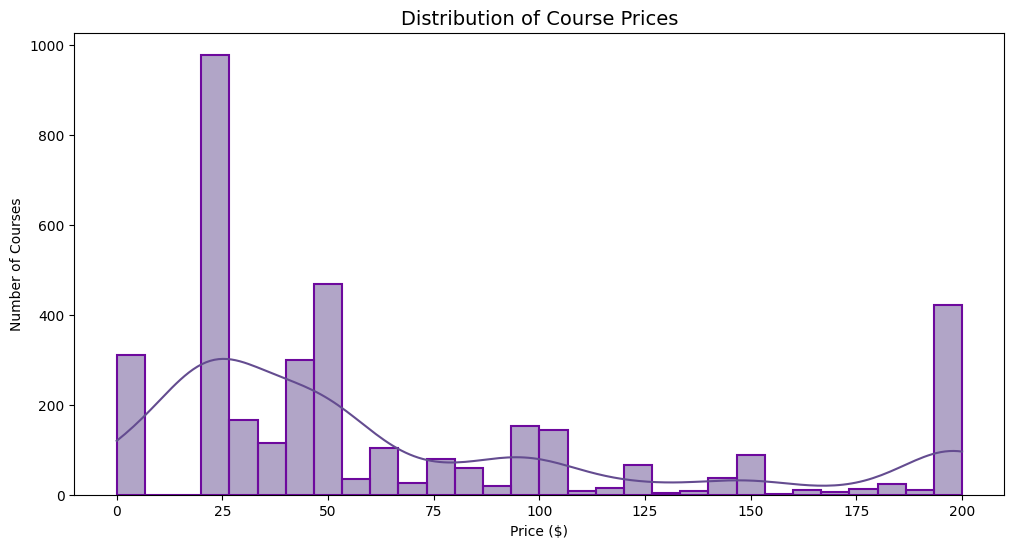

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(
    udemyDf['price'],
    bins=30,
    color='#644C90',
    kde=True,
    edgecolor='#6D099D',
    linewidth=1.5
)

plt.title('Distribution of Course Prices', fontsize=14)
plt.xlabel('Price ($)')
plt.ylabel('Number of Courses')

plt.show()

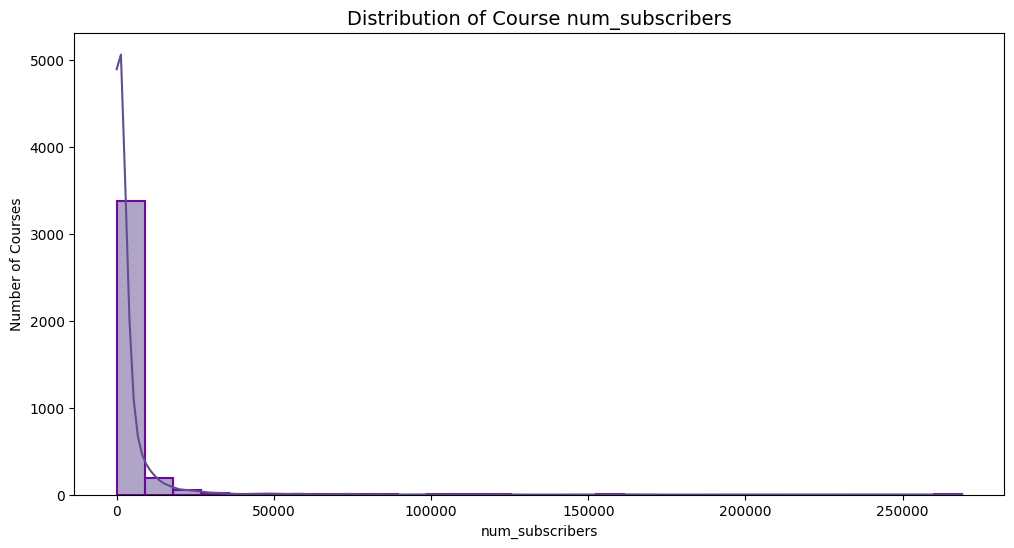

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(
    udemyDf['num_subscribers'],
    bins=30,
    color='#644C90',
    kde=True,
    edgecolor='#6D099D',
    linewidth=1.5
)

plt.title('Distribution of Course num_subscribers', fontsize=14)
plt.xlabel('num_subscribers')
plt.ylabel('Number of Courses')

plt.show()

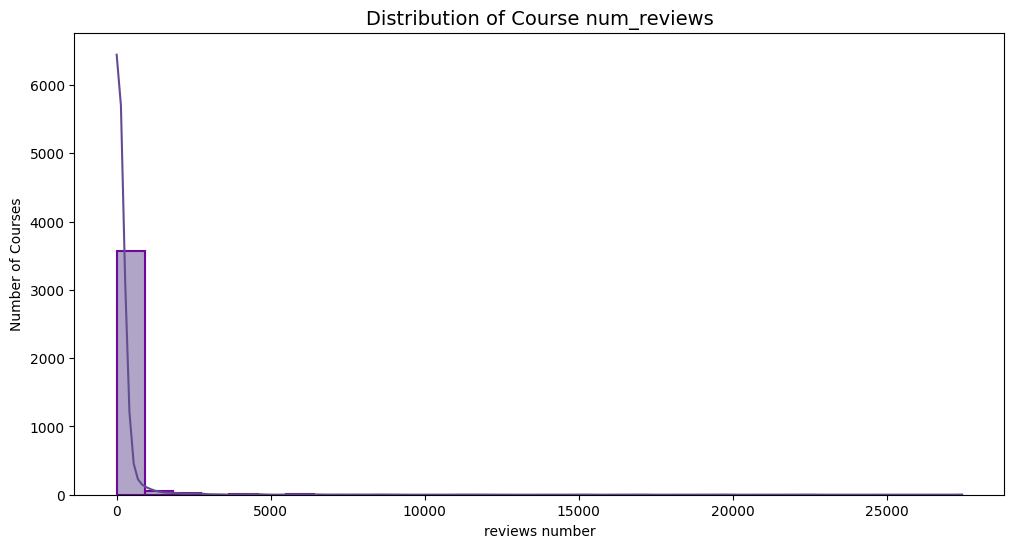

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(
    udemyDf['num_reviews'],
    bins=30,
    color='#644C90',
    kde=True,
    edgecolor='#6D099D',
    linewidth=1.5
)

plt.title('Distribution of Course num_reviews', fontsize=14)
plt.xlabel('reviews number')
plt.ylabel('Number of Courses')

plt.show()

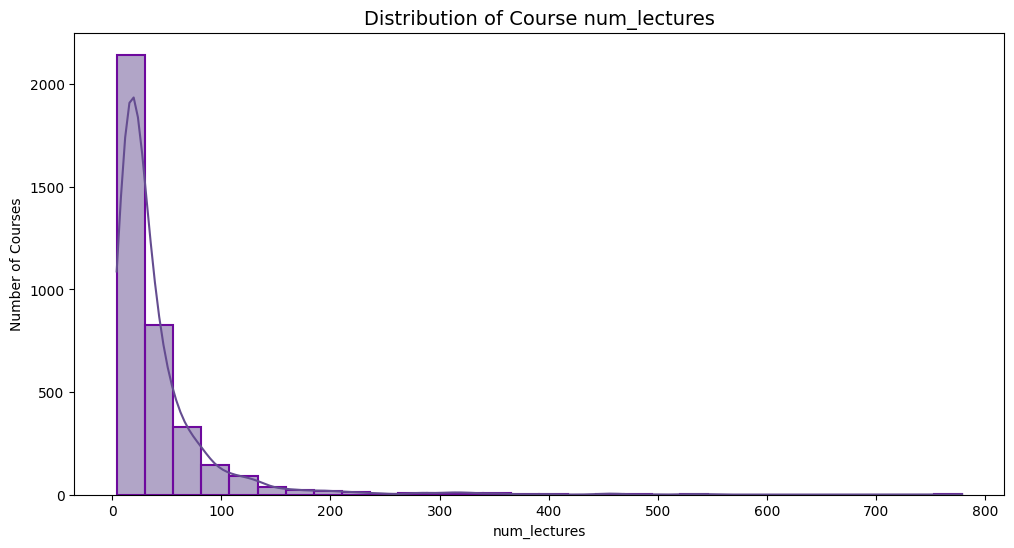

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(
    udemyDf['num_lectures'],
    bins=30,
    color='#644C90',
    kde=True,
    edgecolor='#6D099D',
    linewidth=1.5
)

plt.title('Distribution of Course num_lectures', fontsize=14)
plt.xlabel('num_lectures')
plt.ylabel('Number of Courses')

plt.show()

In [ ]:
subject_counts = udemyDf['subject'].value_counts().reset_index()
subject_counts.columns = ['Subject', 'Number of Courses']
subject_counts['Percentage'] = (subject_counts['Number of Courses'] / subject_counts['Number of Courses'].sum() * 100).round(2)

print(subject_counts)


               Subject  Number of Courses  Percentage
0      Web Development               1199       32.66
1     Business Finance               1190       32.42
2  Musical Instruments                680       18.52
3       Graphic Design                602       16.40


Categories of subject feature:

subject
Web Development        1199
Business Finance       1190
Musical Instruments     680
Graphic Design          602
Name: count, dtype: int64
********************************************************************************


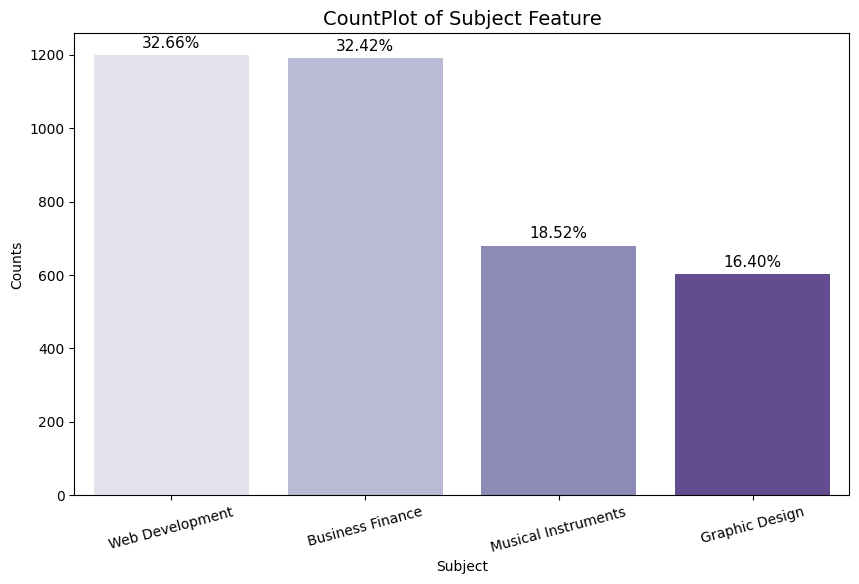

In [ ]:
# Count values
subject_values = udemyDf['subject'].value_counts()

# Print counts
print('Categories of subject feature:\n')
print(subject_values)

print('**' * 40)

# Plotting
plt.figure(figsize=(10,6))

sns.countplot(
    x='subject',
    data=udemyDf,
    order=subject_values.index,
    palette='Purples'
)

plt.title('CountPlot of Subject Feature', fontsize=14)
plt.xlabel('Subject')
plt.ylabel('Counts')

# Show percentages
for i in range(subject_values.shape[0]):

    count = subject_values.iloc[i]

    percentage = '{:0.2f}%'.format(
        100 * count / udemyDf.shape[0]
    )

    plt.text(
        i,
        count + 20,
        percentage,
        ha='center',
        fontsize=11
    )

plt.xticks(rotation=15)
plt.show()

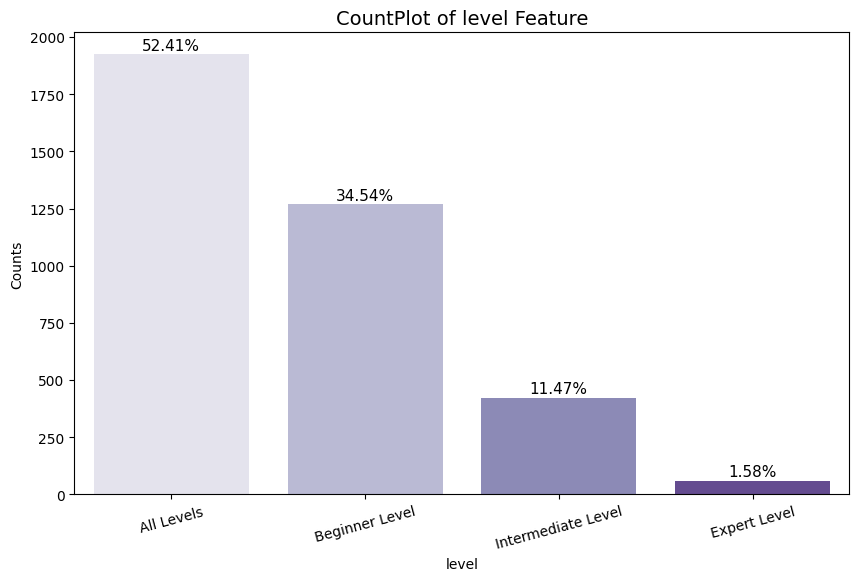

In [ ]:
# Count values
level_values = udemyDf['level'].value_counts()

# Plotting
plt.figure(figsize=(10,6))

sns.countplot(
    x='level',
    data=udemyDf,
    order=level_values.index,
    palette='Purples'
)

plt.title('CountPlot of level Feature', fontsize=14)
plt.xlabel('level')
plt.ylabel('Counts')

# Show percentages
for i in range(level_values.shape[0]):

    count = level_values[i]

    percentage = '{:0.2f}%'.format(
        100 * count / udemyDf.shape[0]
    )

    plt.text(
        i,
        count + 20,
        percentage,
        ha='center',
        fontsize=11
    )

plt.xticks(rotation=15)
plt.show()

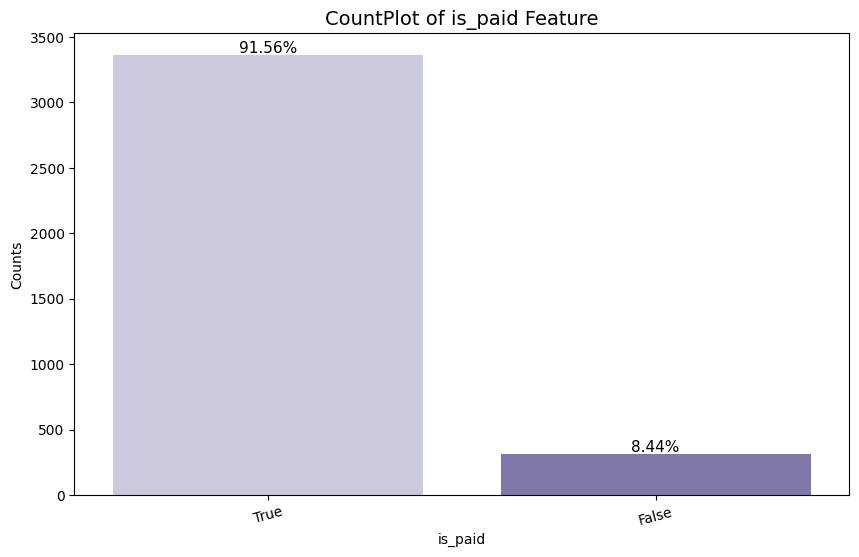

In [ ]:
# Count values
is_paid_values = udemyDf['is_paid'].value_counts()

# Plotting
plt.figure(figsize=(10,6))

sns.countplot(
    x='is_paid',
    data=udemyDf,
    order=is_paid_values.index,
    palette='Purples'
)

plt.title('CountPlot of is_paid Feature', fontsize=14)
plt.xlabel('is_paid')
plt.ylabel('Counts')

# Show percentages
for i in range(is_paid_values.shape[0]):

    count = is_paid_values[i]

    percentage = '{:0.2f}%'.format(
        100 * count / udemyDf.shape[0]
    )

    plt.text(
        i,
        count + 20,
        percentage,
        ha='center',
        fontsize=11
    )

plt.xticks(rotation=15)
plt.show()

## Bivariate Analysis

### Numerical vs Numerical

***price vs subscribers***

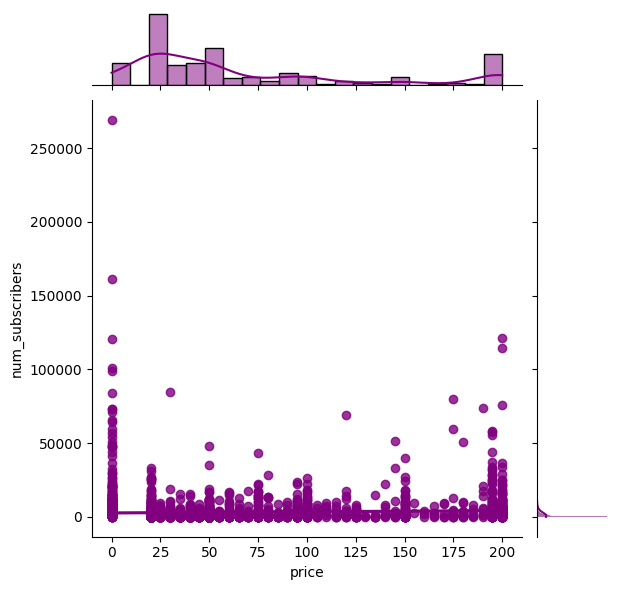

In [ ]:
sns.jointplot(
    x='price',
    y='num_subscribers',
    data=udemyDf,
    kind='reg',
    color='purple'
)
plt.show()

***Insight***

- There is no strong linear relationship between price and number of subscribers.

- Many free or low-priced courses have very high subscriber counts, suggesting that lower prices may attract more students.

- The data contains several outliers with extremely high numbers of subscribers.

- Subscriber distribution is highly right-skewed, with most courses having relatively low enrollment numbers.

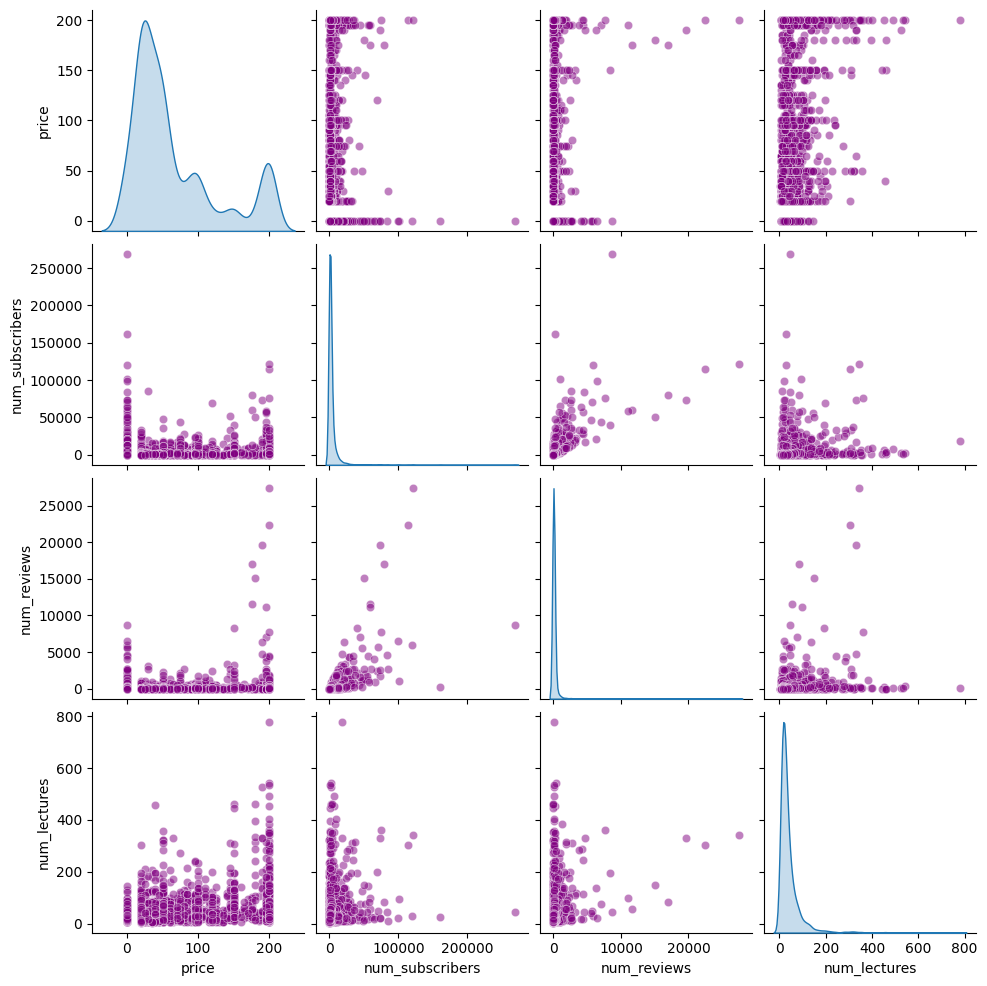

In [ ]:
numerical_cols = ['price', 'num_subscribers', 'num_reviews', 'num_lectures']
sns.pairplot(udemyDf[numerical_cols], diag_kind='kde', plot_kws={'color':'purple', 'alpha':0.5})
plt.show()

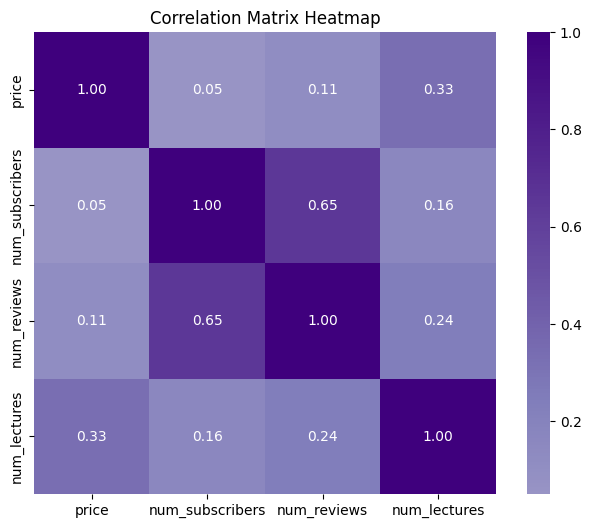

In [ ]:
plt.figure(figsize=(8, 6))
correlation = udemyDf[['price', 'num_subscribers', 'num_reviews', 'num_lectures']].corr()
sns.heatmap(
    correlation,
    annot=True,
    cmap='Purples',
    center=0,
    fmt='.2f',
    square=True
)
plt.title('Correlation Matrix Heatmap')
plt.show()

***content_duration vs num_subscribers***

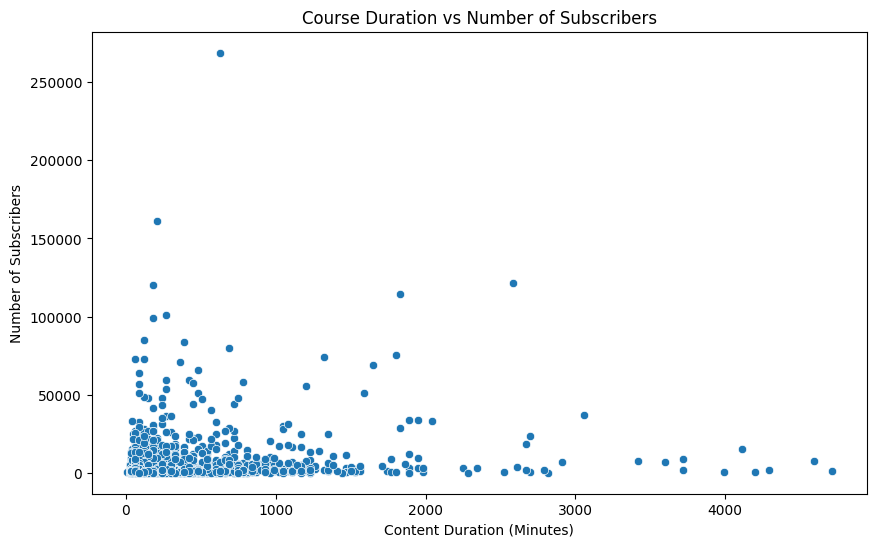

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='content_duration',
    y='num_subscribers',
    data=udemyDf
)

plt.title('Course Duration vs Number of Subscribers')
plt.xlabel('Content Duration (Minutes)')
plt.ylabel('Number of Subscribers')

plt.show()

In [ ]:
udemyDf['content_duration']


,content_duration
0,90.0
1,60.0
2,90.0
3,60.0
4,37.0
...,...
3677,240.0
3678,300.0
3679,390.0
3680,120.0


In [ ]:
correlation = udemyDf['content_duration'].corr(
    udemyDf['num_subscribers']
)

print("Correlation:", correlation)

Correlation: 0.162068443368932


### Categorical vs Numerical

***subject vs subscribers***

In [ ]:
fig = px.box(
    udemyDf,
    x='subject',
    y='num_subscribers',
    color='subject',
    title='Subject vs Subscribers (Interactive)',
    labels={'subject': 'Subject', 'num_subscribers': 'Subscribers'},
    color_discrete_sequence=px.colors.sequential.Purples_r
)

fig.update_layout(
    width=900,
    height=600,
    xaxis_tickangle=-15,
    yaxis_title='Number of Subscribers',
    xaxis_title='Course Subject',
    showlegend=False
)

fig.show()

***level vs subscribers***

In [ ]:

fig = px.box(
    udemyDf,
    x='level',
    y='num_subscribers',
    color='level',
    title='Level vs Subscribers (Interactive)',
    labels={'level': 'Level', 'num_subscribers': 'Subscribers'},
    color_discrete_sequence=px.colors.sequential.Purples_r
)

fig.update_layout(
    width=900,
    height=600,
    xaxis_tickangle=-15,
    yaxis_title='Number of Subscribers',
    xaxis_title='Course Level',
    showlegend=False
)

fig.show()

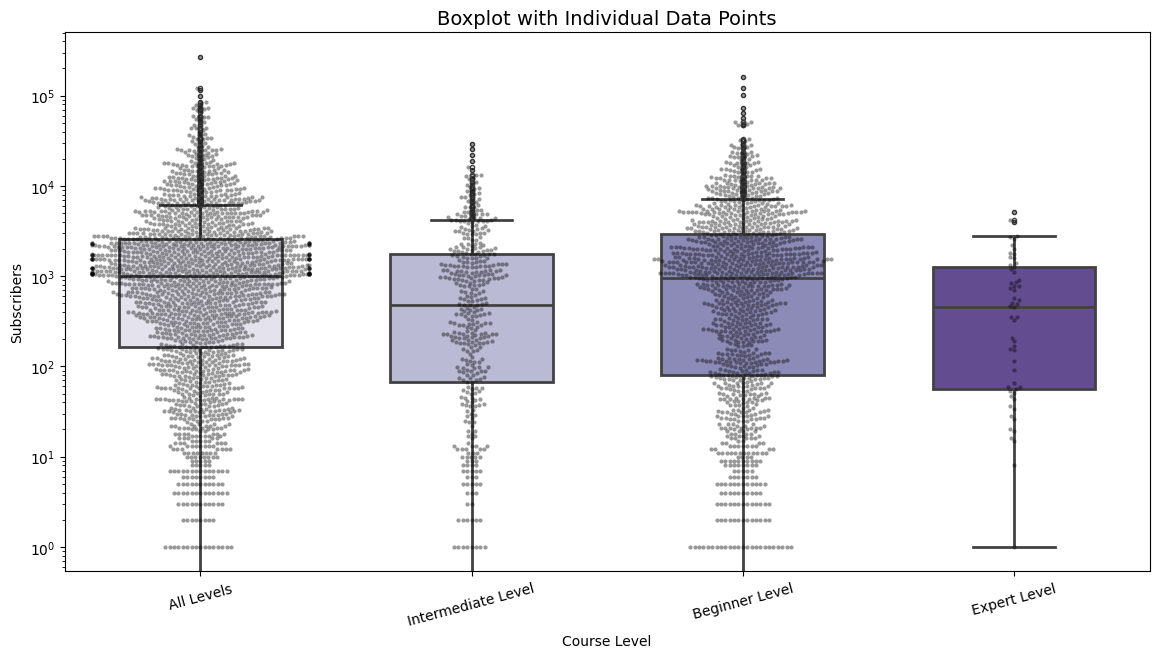

In [ ]:
plt.figure(figsize=(14,7))

sns.boxplot(
    x='level',
    y='num_subscribers',
    data=udemyDf,
    palette='Purples',
    width=0.6,
    fliersize=3,
    linewidth=2
)

# (Swarmplot)
sns.swarmplot(
    x='level',
    y='num_subscribers',
    data=udemyDf,
    color='black',
    alpha=0.4,
    size=3
)

plt.title('Boxplot with Individual Data Points', fontsize=14)
plt.xlabel('Course Level')
plt.ylabel('Subscribers')
plt.xticks(rotation=15)
plt.yscale('log')

plt.show()

***Insight***

- Beginner-level courses tend to attract more subscribers compared to intermediate and expert-level courses.

- Expert-level courses generally have lower median subscriber counts, suggesting they target a smaller audience.

- All course levels contain several outliers with very high subscriber numbers.

- The wide spread of the data indicates high variability in course popularity across all levels

## Check the Correlation between the Features and the Target (num_subscribers)



In [ ]:
udemyDf.corr(numeric_only = True)

,course_id,is_paid,price,num_subscribers,num_reviews,num_lectures,content_duration
course_id,1.000000,-0.013753,0.143045,-0.166110,-0.058317,-0.024768,-0.057266
is_paid,-0.013753,1.000000,0.329002,-0.267036,-0.087432,0.112866,0.094657
price,0.143045,0.329002,1.000000,0.050372,0.113543,0.329834,0.293102
num_subscribers,-0.166110,-0.267036,0.050372,1.000000,0.651068,0.158294,0.162068
num_reviews,-0.058317,-0.087432,0.113543,0.651068,1.000000,0.243004,0.228836
num_lectures,-0.024768,0.112866,0.329834,0.158294,0.243004,1.000000,0.801596
content_duration,-0.057266,0.094657,0.293102,0.162068,0.228836,0.801596,1.000000


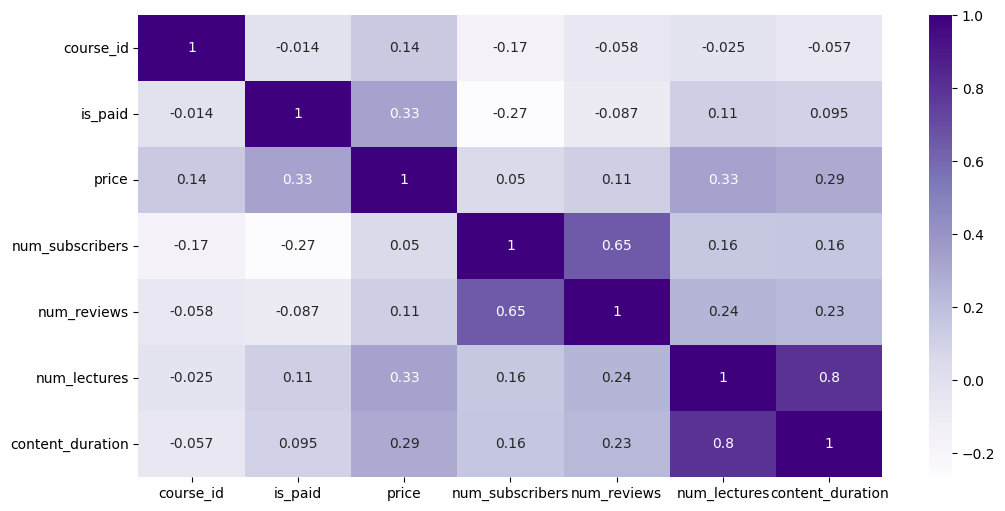

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(udemyDf.corr(numeric_only = True), annot=True, cmap='Purples')  ## symmetric matrix
plt.show()

***Insight***

- A strong positive correlation exists between subscribers and reviews
r=0.65 indicating that popular courses usually receive more reviews.

- The strongest relationship is between number of lectures and content duration
r=0.80 meaning longer courses tend to contain more lectures.

- Price has only a weak relationship with subscribers, suggesting that expensive courses are not always more popular.

# Feature Engineering

🎯  The Target is : `num_subscribers`

***Published Year***

In [ ]:
udemyDf['published_year'] = udemyDf['published_timestamp'].dt.year

***Published Month***

In [ ]:
udemyDf['published_month'] = udemyDf['published_timestamp'].dt.month


In [ ]:
max_year = udemyDf['published_year'].max()

udemyDf['course_age'] = (
    max_year - udemyDf['published_year']
)

In [ ]:
udemyDf

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject,published_year,published_month,course_age
0,288942,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,90.0,2014-09-18 05:07:05+00:00,Musical Instruments,2014,9,3
1,1170074,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593,1,41,Intermediate Level,60.0,2017-04-12 19:06:34+00:00,Musical Instruments,2017,4,0
2,1193886,#12 Hand Coordination: Let your Hands dance wi...,True,75,482,1,47,Intermediate Level,90.0,2017-04-26 18:34:57+00:00,Musical Instruments,2017,4,0
3,1116700,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850,3,43,Intermediate Level,60.0,2017-02-21 23:48:18+00:00,Musical Instruments,2017,2,0
4,1120410,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940,3,32,Intermediate Level,37.0,2017-02-21 23:44:49+00:00,Musical Instruments,2017,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3677,328960,Your Own Site in 45 Min: The Complete Wordpres...,True,120,1566,29,36,All Levels,240.0,2015-04-20 22:15:17+00:00,Web Development,2015,4,2
3678,552700,Your Second Course on Piano: Two Handed Playing,True,70,1018,12,22,Beginner Level,300.0,2015-10-26 20:04:21+00:00,Musical Instruments,2015,10,2
3679,631754,Zend Framework 2: Learn the PHP framework ZF2 ...,True,40,723,130,37,All Levels,390.0,2015-11-11 18:55:45+00:00,Web Development,2015,11,2
3680,1225194,Zoho Books Gestion Financière d'Entreprise pas...,False,0,229,0,33,All Levels,120.0,2017-05-26 16:45:55+00:00,Business Finance,2017,5,0


In [ ]:
udemyDf.isna().sum()

,0
course_id,0
course_title,0
is_paid,0
price,0
num_subscribers,0
num_reviews,0
num_lectures,0
level,0
content_duration,0
published_timestamp,0


In [ ]:
udemyDf['content_duration'].isna().sum()


np.int64(0)

In [ ]:


missing_rows = udemyDf[udemyDf['content_duration'].isna()]
print(missing_rows)

Empty DataFrame
Columns: [course_id, course_title, is_paid, price, num_subscribers, num_reviews, num_lectures, level, content_duration, published_timestamp, subject, published_year, published_month, course_age]
Index: []


In [ ]:
udemyDf.head(20)

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject,published_year,published_month,course_age
0,288942,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,90.0,2014-09-18 05:07:05+00:00,Musical Instruments,2014,9,3
1,1170074,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593,1,41,Intermediate Level,60.0,2017-04-12 19:06:34+00:00,Musical Instruments,2017,4,0
2,1193886,#12 Hand Coordination: Let your Hands dance wi...,True,75,482,1,47,Intermediate Level,90.0,2017-04-26 18:34:57+00:00,Musical Instruments,2017,4,0
3,1116700,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850,3,43,Intermediate Level,60.0,2017-02-21 23:48:18+00:00,Musical Instruments,2017,2,0
4,1120410,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940,3,32,Intermediate Level,37.0,2017-02-21 23:44:49+00:00,Musical Instruments,2017,2,0
5,1122832,#6 Piano Hand Coordination: Play Open 10 Balla...,True,65,2015,3,21,Intermediate Level,44.0,2017-03-08 17:53:36+00:00,Musical Instruments,2017,3,0
6,1123184,#7 Piano Hand Coordination: Play Piano Runs in...,True,65,2015,2,25,Intermediate Level,60.0,2017-03-08 18:09:32+00:00,Musical Instruments,2017,3,0
7,768028,* An Integrated Approach to the Fundamentals o...,True,200,134,14,123,All Levels,330.0,2016-03-15 17:23:07+00:00,Business Finance,2016,3,1
8,206592,:::Beginners Guide To Creating Amazing Images ...,True,25,72,5,17,Beginner Level,60.0,2014-04-29 19:50:31+00:00,Graphic Design,2014,4,3
9,738910,[Value Investing] Where White People Keep Thei...,True,200,2715,70,20,Expert Level,240.0,2016-05-25 21:04:41+00:00,Business Finance,2016,5,1


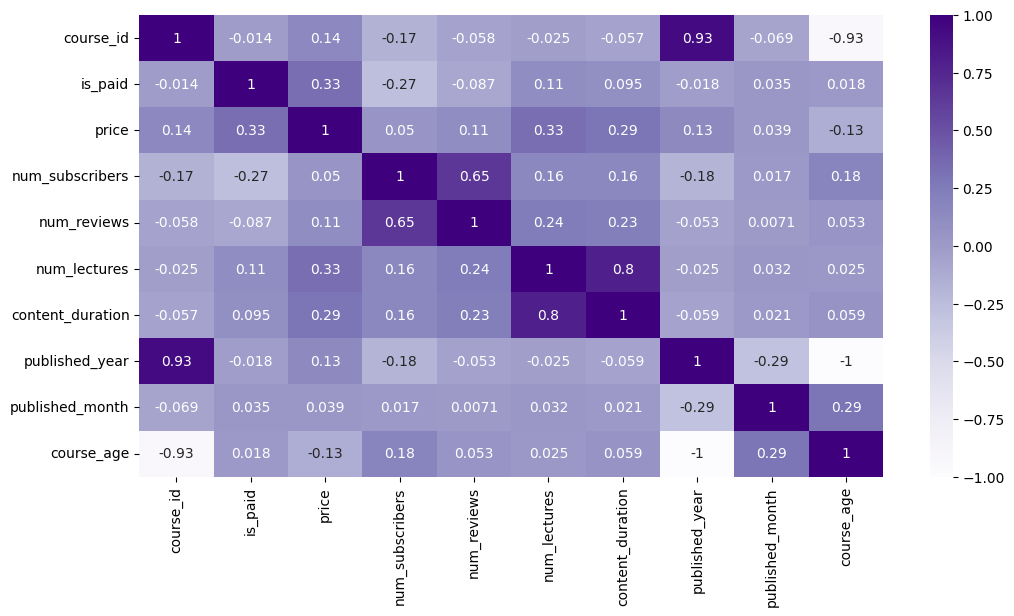

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(udemyDf.corr(numeric_only = True), annot=True, cmap='Purples')  ## symmetric matrix
plt.show()

### Insights

* `published_month` has almost no correlation with `num_subscribers` (`0.017`), so the publishing month does not affect course popularity.

* `published_year` and `course_age` show a weak correlation (`0.18`) with subscribers, meaning older courses may have slightly more subscribers, but the effect is small.

* The strongest relationship with the target was `num_reviews` (`0.65`), indicating that courses with more reviews usually have more subscribers.

* `published_year` and `course_age` are perfectly negatively correlated (`-1`) because they represent the same information inversely, so keeping only `course_age` is recommended.

* `course_id` should be removed since it is only an identifier and not a meaningful predictive feature.


# Data Preprocessing

There is no null values

In [ ]:
udemyDf.isna().sum()

,0
course_id,0
course_title,0
is_paid,0
price,0
num_subscribers,0
num_reviews,0
num_lectures,0
level,0
content_duration,0
published_timestamp,0


### `Dealing Outliers` Data Cleaning


In [ ]:
for col in udemyDf.columns:
    fig = px.box(udemyDf, y=col, title=f'Boxplot of {col}')
    fig.show()

In [ ]:
numeric_cols = udemyDf.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    Q1 = udemyDf[col].quantile(0.25)
    Q3 = udemyDf[col].quantile(0.75)
    IQR = Q3 - Q1
    median = udemyDf[col].median()

    udemyDf[col] = udemyDf[col].apply(lambda x: median if x < (Q1 - 1.5*IQR) or x > (Q3 + 1.5*IQR) else x)

udemyDf.head()

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject,published_year,published_month,course_age
0,288942,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137.0,18.0,68.0,All Levels,90.0,2014-09-18 05:07:05+00:00,Musical Instruments,2014.0,9,3.0
1,1170074,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593.0,1.0,41.0,Intermediate Level,60.0,2017-04-12 19:06:34+00:00,Musical Instruments,2017.0,4,0.0
2,1193886,#12 Hand Coordination: Let your Hands dance wi...,True,75,482.0,1.0,47.0,Intermediate Level,90.0,2017-04-26 18:34:57+00:00,Musical Instruments,2017.0,4,0.0
3,1116700,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850.0,3.0,43.0,Intermediate Level,60.0,2017-02-21 23:48:18+00:00,Musical Instruments,2017.0,2,0.0
4,1120410,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940.0,3.0,32.0,Intermediate Level,37.0,2017-02-21 23:44:49+00:00,Musical Instruments,2017.0,2,0.0


In [ ]:
for col in udemyDf.columns:
    fig = px.box(udemyDf, y=col, title=f'Boxplot of {col}')
    fig.show()

#### Drop Column : `course_id` - `course_title` - `published_timestamp	`


In [ ]:
udemyDf.drop(columns=['course_id', 'course_title', 'published_timestamp'], inplace=True, errors='ignore')

In [ ]:
udemyDf.head(30)

,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,published_year,published_month,course_age
0,True,35,3137.0,18.0,68.0,All Levels,90.0,Musical Instruments,2014.0,9,3.0
1,True,75,1593.0,1.0,41.0,Intermediate Level,60.0,Musical Instruments,2017.0,4,0.0
2,True,75,482.0,1.0,47.0,Intermediate Level,90.0,Musical Instruments,2017.0,4,0.0
3,True,75,850.0,3.0,43.0,Intermediate Level,60.0,Musical Instruments,2017.0,2,0.0
4,True,75,940.0,3.0,32.0,Intermediate Level,37.0,Musical Instruments,2017.0,2,0.0
5,True,65,2015.0,3.0,21.0,Intermediate Level,44.0,Musical Instruments,2017.0,3,0.0
6,True,65,2015.0,2.0,25.0,Intermediate Level,60.0,Musical Instruments,2017.0,3,0.0
7,True,200,134.0,14.0,25.0,All Levels,330.0,Business Finance,2016.0,3,1.0
8,True,25,72.0,5.0,17.0,Beginner Level,60.0,Graphic Design,2014.0,4,3.0
9,True,200,2715.0,70.0,20.0,Expert Level,240.0,Business Finance,2016.0,5,1.0


### `Categorical Features Encoding`

***is_paid***

In [ ]:
udemyDf['is_paid'] = udemyDf['is_paid'].astype(int)

***level, subject***

In [ ]:
udemyDf = pd.get_dummies(udemyDf, columns=['level', 'subject'], drop_first=True)

In [ ]:
udemyDf.head(20)

,is_paid,price,num_subscribers,num_reviews,num_lectures,content_duration,published_year,published_month,course_age,level_Beginner Level,level_Expert Level,level_Intermediate Level,subject_Graphic Design,subject_Musical Instruments,subject_Web Development
0,1,35,3137.0,18.0,68.0,90.0,2014.0,9,3.0,False,False,False,False,True,False
1,1,75,1593.0,1.0,41.0,60.0,2017.0,4,0.0,False,False,True,False,True,False
2,1,75,482.0,1.0,47.0,90.0,2017.0,4,0.0,False,False,True,False,True,False
3,1,75,850.0,3.0,43.0,60.0,2017.0,2,0.0,False,False,True,False,True,False
4,1,75,940.0,3.0,32.0,37.0,2017.0,2,0.0,False,False,True,False,True,False
5,1,65,2015.0,3.0,21.0,44.0,2017.0,3,0.0,False,False,True,False,True,False
6,1,65,2015.0,2.0,25.0,60.0,2017.0,3,0.0,False,False,True,False,True,False
7,1,200,134.0,14.0,25.0,330.0,2016.0,3,1.0,False,False,False,False,False,False
8,1,25,72.0,5.0,17.0,60.0,2014.0,4,3.0,True,False,False,True,False,False
9,1,200,2715.0,70.0,20.0,240.0,2016.0,5,1.0,False,True,False,False,False,False


# Split the Dataset

In [ ]:
X = udemyDf.drop(columns=['num_subscribers'], axis=1)  ## features

y = udemyDf['num_subscribers']  ## target

In [ ]:
X.shape

(3671, 14)

In [ ]:
y.shape

(3671,)

In [ ]:
X.head()

,is_paid,price,num_reviews,num_lectures,content_duration,published_year,published_month,course_age,level_Beginner Level,level_Expert Level,level_Intermediate Level,subject_Graphic Design,subject_Musical Instruments,subject_Web Development
0,1,35,18.0,68.0,90.0,2014.0,9,3.0,False,False,False,False,True,False
1,1,75,1.0,41.0,60.0,2017.0,4,0.0,False,False,True,False,True,False
2,1,75,1.0,47.0,90.0,2017.0,4,0.0,False,False,True,False,True,False
3,1,75,3.0,43.0,60.0,2017.0,2,0.0,False,False,True,False,True,False
4,1,75,3.0,32.0,37.0,2017.0,2,0.0,False,False,True,False,True,False


In [ ]:
y.head()

,num_subscribers
0,3137.0
1,1593.0
2,482.0
3,850.0
4,940.0


## Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [ ]:
## check shape
print('X_train shape -- ', X_train.shape)
print('y_train shape -- ', y_train.shape)

print('X_test shape -- ', X_test.shape)
print('y_test shape -- ', y_test.shape)

X_train shape --  (2936, 14)
y_train shape --  (2936,)
X_test shape --  (735, 14)
y_test shape --  (735,)


## Standardize the Dataset


## StandardScaler

In [ ]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled

array([[ 0.29836349,  0.15454061, -0.49056113, ..., -0.44373613,
        -0.48655036, -0.69971365],
       [ 0.29836349, -0.7602401 , -0.45998891, ..., -0.44373613,
        -0.48655036,  1.42915606],
       [ 0.29836349,  2.23358769,  0.85461619, ..., -0.44373613,
        -0.48655036,  1.42915606],
       ...,
       [ 0.29836349, -0.7602401 , -0.76571103, ..., -0.44373613,
        -0.48655036, -0.69971365],
       [ 0.29836349,  0.73667379, -0.24598343, ..., -0.44373613,
        -0.48655036,  1.42915606],
       [ 0.29836349,  2.23358769,  3.33096534, ..., -0.44373613,
        -0.48655036, -0.69971365]])

In [ ]:
X_test_scaled

array([[ 0.29836349, -0.42759257,  0.70175513, ...,  2.25359157,
        -0.48655036, -0.69971365],
       [ 0.29836349, -0.59391634, -0.76571103, ..., -0.44373613,
        -0.48655036, -0.69971365],
       [ 0.29836349, -0.67707822, -0.70456661, ..., -0.44373613,
        -0.48655036, -0.69971365],
       ...,
       [ 0.29836349, -0.67707822,  0.02916647, ..., -0.44373613,
        -0.48655036,  1.42915606],
       [ 0.29836349, -0.51075445, -0.55170555, ..., -0.44373613,
        -0.48655036, -0.69971365],
       [ 0.29836349, -0.59391634, -0.61284997, ..., -0.44373613,
        -0.48655036, -0.69971365]])

In [ ]:
## using StandardScaler for each Feature to be (mean=0, std=1)
## This techniques helps for better training and to converge faster and put all features in the same scale
#scaler = StandardScaler()  ## define an instance

## fit and transform to training data (only Numerical)
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_train_final

,is_paid,price,num_reviews,num_lectures,content_duration,published_year,published_month,course_age,level_Beginner Level,level_Expert Level,level_Intermediate Level,subject_Graphic Design,subject_Musical Instruments,subject_Web Development
0,0.298363,0.154541,-0.490561,-0.352050,-0.588974,0.359741,-1.222896,-0.359741,-0.731274,-0.126162,-0.366099,-0.443736,-0.48655,-0.699714
1,0.298363,-0.760240,-0.459989,-0.195307,-0.331781,1.423386,-0.633190,-1.423386,-0.731274,-0.126162,-0.366099,-0.443736,-0.48655,1.429156
2,0.298363,2.233588,0.854616,0.013685,-0.331781,-0.703904,1.430779,0.703904,-0.731274,-0.126162,-0.366099,-0.443736,-0.48655,1.429156
3,0.298363,-0.760240,0.610038,0.222676,1.211375,0.359741,-1.222896,-0.359741,-0.731274,-0.126162,-0.366099,2.253592,-0.48655,-0.699714
4,-3.351617,-1.092888,-0.245983,-1.083520,-1.060494,-1.767549,0.546221,1.767549,1.367476,-0.126162,-0.366099,-0.443736,-0.48655,1.429156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2931,0.298363,-0.760240,-0.521133,-0.195307,-0.331781,-0.703904,-1.517748,0.703904,1.367476,-0.126162,-0.366099,-0.443736,-0.48655,1.429156
2932,-3.351617,-1.092888,-0.245983,-0.508794,-0.331781,1.423386,-1.222896,-1.423386,-0.731274,-0.126162,2.731501,-0.443736,-0.48655,1.429156
2933,0.298363,-0.760240,-0.765711,-0.247554,-0.331781,-0.703904,-0.633190,0.703904,-0.731274,-0.126162,-0.366099,-0.443736,-0.48655,-0.699714
2934,0.298363,0.736674,-0.245983,-0.195307,2.240146,0.359741,0.841073,-0.359741,-0.731274,-0.126162,-0.366099,-0.443736,-0.48655,1.429156


In [ ]:
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)
X_test_final

,is_paid,price,num_reviews,num_lectures,content_duration,published_year,published_month,course_age,level_Beginner Level,level_Expert Level,level_Intermediate Level,subject_Graphic Design,subject_Musical Instruments,subject_Web Development
0,0.298363,-0.427593,0.701755,3.096308,2.497339,0.359741,-1.517748,-0.359741,1.367476,-0.126162,-0.366099,2.253592,-0.48655,-0.699714
1,0.298363,-0.593916,-0.765711,-0.404298,0.439797,-1.767549,1.725632,1.767549,-0.731274,-0.126162,-0.366099,-0.443736,-0.48655,-0.699714
2,0.298363,-0.677078,-0.704567,-0.717785,-0.588974,0.359741,1.430779,-0.359741,1.367476,-0.126162,-0.366099,-0.443736,-0.48655,-0.699714
3,0.298363,-0.593916,-0.551706,-0.456546,-0.588974,0.359741,0.841073,-0.359741,-0.731274,-0.126162,-0.366099,2.253592,-0.48655,-0.699714
4,0.298363,-0.344431,-0.612850,-1.083520,-1.069067,1.423386,-1.222896,-1.423386,-0.731274,-0.126162,-0.366099,-0.443736,-0.48655,1.429156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,0.298363,-0.760240,-0.582278,-0.404298,-0.846166,0.359741,0.251368,-0.359741,-0.731274,-0.126162,-0.366099,2.253592,-0.48655,-0.699714
731,0.298363,2.150426,-0.245983,0.901898,0.696990,-0.703904,1.725632,0.703904,-0.731274,-0.126162,-0.366099,-0.443736,-0.48655,1.429156
732,0.298363,-0.677078,0.029166,1.633368,1.982953,-0.703904,1.135926,0.703904,-0.731274,-0.126162,-0.366099,-0.443736,-0.48655,1.429156
733,0.298363,-0.510754,-0.551706,-0.404298,-0.846166,0.359741,-0.928043,-0.359741,-0.731274,-0.126162,-0.366099,-0.443736,-0.48655,-0.699714


# ` ML Models`


## `LinearRegression`

In [ ]:
lr = LinearRegression()
lr.fit(X_train_final, y_train)

LinearRegression()

In [ ]:
lr.score(X_train_final, y_train)

0.22019801347453838

In [ ]:
y_pred = lr.predict(X_test_final)

In [ ]:
metrics.mean_squared_error(y_test, y_pred)

1540000.5135767937

In [ ]:
metrics.mean_absolute_error(y_test, y_pred)

898.0507061824035

In [ ]:
print("Accuracy --> ",metrics.r2_score(y_test, y_pred)*100)

Accuracy -->  20.834498543390623


## DecisionTreeRegressor

In [ ]:
dt = DecisionTreeRegressor(max_depth=8,random_state=42)

In [ ]:
dt.fit(X_train_final, y_train)

DecisionTreeRegressor(max_depth=8, random_state=42)

In [ ]:
print("Accuracy in train--> ",dt.score(X_train_final, y_train)*100)
print("Accuracy in test--> ",dt.score(X_test_final , y_test)*100)

Accuracy in train-->  49.46852313848154
Accuracy in test-->  14.692914380206313


In [ ]:
y_pred = dt.predict(X_test_final)
print("mean_squared_error=",metrics.mean_squared_error(y_test, y_pred))
 #Train
 # test

print("mean_absolute_error=",metrics.mean_absolute_error(y_test, y_pred))

mean_squared_error= 1659472.285894978
mean_absolute_error= 860.4207160220842


In [ ]:
y_test

,num_subscribers
179,290.0
3550,274.0
321,148.0
1476,65.0
3657,396.0
...,...
1580,5000.0
3293,912.0
1795,3249.0
2898,83.0


In [ ]:
y_pred

array([1111.43902439,  234.14      ,  371.3902439 ,  117.31818182,
        785.8       ,  862.26415094,  462.78947368,  251.59401709,
       1056.78313253, 1111.43902439, 1818.        , 1111.43902439,
        462.78947368,  251.59401709, 1318.91666667, 1889.72093023,
       1268.        , 1209.28368794, 1758.1122449 ,  272.4375    ,
       2276.01075269, 1113.63636364,  117.31818182,  234.14      ,
       2276.01075269,  991.1       , 1282.77777778, 1119.96341463,
         44.        , 1889.72093023,  371.3902439 ,  462.78947368,
       1111.43902439, 2276.01075269, 1517.375     , 2276.01075269,
        379.03030303,  251.59401709, 1399.06666667,  512.55932203,
        991.1       , 1985.52      ,  104.19148936,    9.05797101,
       1184.7       , 1537.        , 1056.78313253,   44.59459459,
         42.67741935,   38.44444444,  251.59401709, 1217.03571429,
       1026.01694915,  251.59401709,  862.26415094, 1056.78313253,
       1209.28368794,  462.78947368,   44.        , 1750.03125

## Random Forest Regressor

In [ ]:
regressor = RandomForestRegressor(n_estimators=50,max_depth=10,random_state=0 ,max_samples=0.8)

In [ ]:
regressor.fit(X_train_final, y_train)

RandomForestRegressor(max_depth=10, max_samples=0.8, n_estimators=50,
                      random_state=0)

In [ ]:
print("Accuracy in train--> ",regressor.score(X_train_final, y_train)*100)
print("Accuracy in test--> ",regressor.score(X_test_final , y_test)*100)

Accuracy in train-->  65.09078779520311
Accuracy in test-->  28.867301078845497


In [ ]:
y_pred = regressor.predict(X_test_final)
print("mean_squared_error=",metrics.mean_squared_error(y_test, y_pred))
print("mean_absolute_error=",metrics.mean_absolute_error(y_test, y_pred))

mean_squared_error= 1383739.0132711113
mean_absolute_error= 819.850297249262


In [ ]:
# R Squared error
error_score = metrics.r2_score(y_test,y_pred )
print('R squared error : ', error_score *100)

R squared error :  28.867301078845497


## Gradient Boosting Regressor


In [ ]:
GBR = GradientBoostingRegressor(n_estimators= 100, max_depth=5)

In [ ]:
gbr = GBR.fit(X_train_final, y_train)

In [ ]:
print("Accuracy in train--> ",gbr.score(X_train_final, y_train)*100)
print("Accuracy in test--> ",gbr.score(X_test_final , y_test)*100)

Accuracy in train-->  63.86199725981182
Accuracy in test-->  28.16022689433292


In [ ]:
# prediction on Test Data
test_data_prediction1 = gbr.predict((X_test_final))

In [ ]:
# R Squared error
error_score = metrics.r2_score(y_test, test_data_prediction1 ) # coefficient of determination, regression score function.
print('R squared error : ', error_score *100)

R squared error :  28.16022689433292


In [ ]:
y_pred = gbr.predict(X_test_final)

print("mean_squared_error=",metrics.mean_squared_error(y_test, y_pred))
print("mean_absolute_error=",metrics.mean_absolute_error(y_test, y_pred))

mean_squared_error= 1397493.6739155976
mean_absolute_error= 812.236121283366


## XGboost


In [ ]:
xg = xgboost.XGBRegressor(n_estimators=50,max_depth=10,random_state=0 ,max_samples=0.8)

In [ ]:
xg.fit(X_train_final, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, max_samples=0.8, min_child_weight=None,
             missing=nan, monotone_constraints=None, multi_strategy=None,
             n_estimators=50, n_jobs=None, ...)

In [ ]:
print("Accuracy in train--> ",xg.score(X_train_final, y_train)*100)
print("Accuracy in test--> ",xg.score(X_test_final , y_test)*100)

Accuracy in train-->  99.27048019543419
Accuracy in test-->  20.28065434416565


In [ ]:
y_pred = xg.predict(X_test_final)
print("mean_squared_error=",metrics.mean_squared_error(y_test, y_pred))
print("mean_absolute_error=",metrics.mean_absolute_error(y_test, y_pred))

mean_squared_error= 1550774.402904274
mean_absolute_error= 836.8758949912324


In [ ]:
# R Squared error
error_score = metrics.r2_score(y_test,y_pred )
print('R squared error : ', error_score *100)


R squared error :  20.28065434416565
